In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import itertools as itt
from sklearn.decomposition import PCA
from common import evaluations_dir
from training_configuration import PATHWAYS_3

data = "dream_cytof"

par_dev_df = pd.concat(
    [
        pd.read_csv(evaluations_dir / model / data/ "param_devs_figure3.csv", index_col=0).assign(model=model)
        for model in PATHWAYS_3
    ]
)

not_param_cols = [
    "cell_line", "context", "model", "features", "samples", "dataset", "l1reg_inflater_output", "inflater_output_reg_epoch", "recon_loss", "inflater_bound", "n_epoch", "job"
]
param_cols = [col for col in par_dev_df.columns if col not in not_param_cols]

median_par_dev_df = par_dev_df.groupby(["context", "features", "cell_line", "samples"])[param_cols].median().reset_index()


def pca_param_devs(par_dev_df):
    results_dfs = []
    for ctxt, split in itt.product(par_dev_df.context.unique(), par_dev_df.samples.unique()):
        sub_df = par_dev_df[(par_dev_df.context == ctxt) & (par_dev_df.samples == split)]
        # Compute median across job/multistart
        sub_df = sub_df.groupby(["context", "samples", "cell_line"])[param_cols].median().reset_index()
        sub_df.set_index("cell_line", inplace=True)
        pca = PCA(n_components=2)
        temp_res = pd.DataFrame(
            pca.fit_transform(sub_df[param_cols]),
            sub_df.index,
            columns=["PC1", "PC2"]
        ).assign(context=ctxt, samples=split)
        results_dfs.append(temp_res)
    return pd.concat(results_dfs)

pca_param_df = pd.concat(
    [
        pca_param_devs(par_dev_df[par_dev_df.model == model]).assign(model=model)
        for model in PATHWAYS_3
    ]
)

In [2]:
pca_param_df

,PC1,PC2,context,samples,model
cell_line,,,,,
c184A1,2.888658,0.176104,cytof_init,BT20,EGFR_MAPK__logobs
c184B5,1.969811,-1.118730,cytof_init,BT20,EGFR_MAPK__logobs
cBT20,-3.410384,0.047651,cytof_init,BT20,EGFR_MAPK__logobs
cBT474,0.299879,-0.210468,cytof_init,BT20,EGFR_MAPK__logobs
cBT483,1.822544,0.659412,cytof_init,BT20,EGFR_MAPK__logobs
...,...,...,...,...,...
cUACC3199,5.666457,0.428364,cytof_init_plus_intr,UACC3199,EGFR_MAPK__logobs_perbb2_aggavg
cUACC812,-3.091280,0.875093,cytof_init_plus_intr,UACC3199,EGFR_MAPK__logobs_perbb2_aggavg
cUACC893,-4.564035,-0.824810,cytof_init_plus_intr,UACC3199,EGFR_MAPK__logobs_perbb2_aggavg


In [5]:
par_dev_df.groupby(["model", "context", "features", "samples", "cell_line"])[param_cols].median()

ERBB2_dp_Y1248_kcat  \
model                           context            features       samples  cell_line                        
EGFR_MAPK__logobs               cytof_init         RFE_10_permute BT20     c184A1               -0.082009   
                                                                           c184B5                0.201213   
                                                                           cBT20                 0.004569   
                                                                           cBT474                0.043177   
                                                                           cBT483               -0.182279   
...                                                                                                   ...   
EGFR_MAPK__logobs_terbb2_aggavg cytof_init_plus_lb RFE_10_permute UACC3199 cUACC3199            -0.787524   
                                                                           cUACC812              0.506136   
                                                                           cUACC893              0.666845   
                                                                           cZR751                0.029770   
                                                                           cZR7530               0.054212   

                                                                                      EGFR_deg_kdeg  \
model                           context            features       samples  cell_line                  
EGFR_MAPK__logobs               cytof_init         RFE_10_permute BT20     c184A1          0.000000   
                                                                           c184B5          0.000000   
                                                                           cBT20           0.000000   
                                                                           cBT474          0.000000   
                                                                           cBT483          0.000000   
...                                                                                             ...   
EGFR_MAPK__logobs_terbb2_aggavg cytof_init_plus_lb RFE_10_permute UACC3199 cUACC3199      -1.315766   
                                                                           cUACC812       -0.792905   
                                                                           cUACC893        0.762622   
                                                                           cZR751         -0.099586   
                                                                           cZR7530        -0.468409   

                                                                                      EGFR_dp_Y1173_kcat  \
model                           context            features       samples  cell_line                       
EGFR_MAPK__logobs               cytof_init         RFE_10_permute BT20     c184A1                    0.0   
                                                                           c184B5                    0.0   
                                                                           cBT20                    -0.0   
                                                                           cBT474                   -0.0   
                                                                           cBT483                    0.0   
...                                                                                                  ...   
EGFR_MAPK__logobs_terbb2_aggavg cytof_init_plus_lb RFE_10_permute UACC3199 cUACC3199                 0.0   
                                                                           cUACC812                 -0.0   
                                                                           cUACC893                 -0.0   
                                                                           cZR751                   -0.0   
                                

Focusing on tEGFR_aggavg, cytof_init context

In [34]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

def test_per_split(df: pd.DataFrame, param_cols: list[str], test_correction="fdr_bh", min_splits=3) -> pd.DataFrame:

    # aggregate across jobs
    agg_df = (
        df.groupby(["model", "context", "features", "samples", "cell_line"])[param_cols]
        .median()
        .reset_index()
    )


    model_res = []
    for model in df.model.unique():
        results = []
        sub_df = agg_df[agg_df.model == model]
        # test within each CV split
        for (ctx, feat, split), group in sub_df.groupby(["context", "features", "samples"]):
            pvals, param_names = [], []
            for param in param_cols:
                values = group[param].dropna().values
                if len(values) < 5:
                    continue
                try:
                    _, p = wilcoxon(np.abs(values))
                except ValueError:
                    p = 1.0
                pvals.append(p)
                param_names.append(param)

            if pvals:
                reject, pvals_corr, _, _ = multipletests(pvals, method=test_correction)
                for param, raw_p, corr_p, sig in zip(param_names, pvals, pvals_corr, reject):
                    results.append({
                        "model": model,
                        "context": ctx,
                        "features": feat,
                        "split": split,
                        "parameter": param,
                        "pval_raw": raw_p,
                        "pval_corr": corr_p,
                        "significant": sig
                    })

        per_split = pd.DataFrame(results)

        # aggregate across splits: keep only parameters significant in ≥ min_splits
        final = (
            per_split.groupby(["model", "context", "features", "parameter"])["significant"]
            .sum()
            .reset_index(name="n_significant_splits")
        )
        final["robust"] = final["n_significant_splits"] >= min_splits

        model_res.append(final.assign(model=model))

    return pd.concat(model_res)

# Example usage:
param_cols = [
    c for c in par_dev_df.columns
    if c not in [
        "model",
        "context",
        "features",
        "samples",
        "job",
        "cell_line",
        "dataset",
        "ref",
        "n_hidden",
        "depth",
        "l1reg_inflater_output",
        "l2reg_inflater_output",
        "inflater_bound",
        "inflater_output_reg_epoch",
        "recon_loss",
        "n_epoch"
    ]
]
# print(param_cols)
results_df = test_per_split(
    par_dev_df,
    param_cols,
    "bonferroni",
    4
)

# Results: per (context, features, parameter) with corrected significance
results_df

,model,context,features,parameter,n_significant_splits,robust
0,EGFR_MAPK__logobs,cytof_init,RFE_10_permute,EGFR_deg_bact,0,False
1,EGFR_MAPK__logobs,cytof_init,RFE_10_permute,EGFR_deg_kdeg,0,False
2,EGFR_MAPK__logobs,cytof_init,RFE_10_permute,EGFR_dp_Y1173_kcat,0,False
3,EGFR_MAPK__logobs,cytof_init,RFE_10_permute,EGFR_endo_EGFR__Y1173_p_kw,0,False
4,EGFR_MAPK__logobs,cytof_init,RFE_10_permute,EGFR_endo_EGFR_kw,1,False
...,...,...,...,...,...,...
97,EGFR_MAPK__logobs_perbb2_aggavg,cytof_init_plus_lb,RFE_10_permute,RPS6KA1_dp_S380_kcat,0,False
98,EGFR_MAPK__logobs_perbb2_aggavg,cytof_init_plus_lb,RFE_10_permute,RPS6KA1_p_S380_EGFR__Y1173_p_kw,5,True
99,EGFR_MAPK__logobs_perbb2_aggavg,cytof_init_plus_lb,RFE_10_permute,RPS6KA1_p_S380_ERBB2__Y1248_p_kw,5,True
100,EGFR_MAPK__logobs_perbb2_aggavg,cytof_init_plus_lb,RFE_10_permute,RPS6KA1_p_S380_ERK__Y204_p_kw,5,True


In [35]:
results_df.groupby(["model", "context", "features"]).robust.sum()

model                            context               features      
EGFR_MAPK__logobs                cytof_init            RFE_10_permute    16
                                 cytof_init_plus_intr  RFE_10_permute    18
                                 cytof_init_plus_lb    RFE_10_permute    18
EGFR_MAPK__logobs_perbb2_aggavg  cytof_init            RFE_10_permute    21
                                 cytof_init_plus_intr  RFE_10_permute    20
                                 cytof_init_plus_lb    RFE_10_permute    21
EGFR_MAPK__logobs_tegfr_aggavg   cytof_init            RFE_10_permute    17
                                 cytof_init_plus_intr  RFE_10_permute    17
                                 cytof_init_plus_lb    RFE_10_permute    18
EGFR_MAPK__logobs_terbb2_aggavg  cytof_init            RFE_10_permute    21
                                 cytof_init_plus_intr  RFE_10_permute    22
                                 cytof_init_plus_lb    RFE_10_permute    22
Name: robust, dtyp

In [36]:
robust_params_tegfr = results_df[
    (results_df.model == "EGFR_MAPK__logobs_tegfr_aggavg") &
    (results_df.context == "cytof_init") & (results_df.robust)
].parameter.unique().tolist()

In [37]:
robust_params_tegfr

['EGFR_p_Y1173_EGF_0_kw',
 'EGFR_p_Y1173_iEGFR_0_kw',
 'ERBB2_dp_Y1248_kcat',
 'ERBB2_p_Y1248_EGFR__Y1173_p_kw',
 'ERBB2_p_Y1248_ERBB2_kw',
 'ERBB2_p_Y1248_iEGFR_0_kw',
 'ERK_p_Y204_EGFR__Y1173_p_kw',
 'ERK_p_Y204_ERBB2__Y1248_p_kw',
 'ERK_p_Y204_MEK__S222_p_kw',
 'ERK_p_Y204_iMEK_0_kw',
 'MEK_p_S222_EGFR__Y1173_p_kw',
 'MEK_p_S222_ERBB2__Y1248_p_kw',
 'MEK_p_S222_bact',
 'RPS6KA1_p_S380_EGFR__Y1173_p_kw',
 'RPS6KA1_p_S380_ERBB2__Y1248_p_kw',
 'RPS6KA1_p_S380_ERK__Y204_p_kw',
 'RPS6KA1_p_S380_bact']

In [38]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.stats import ranksums

def cluster_drivers(df: pd.DataFrame, param_cols: list[str], method="ward") -> pd.DataFrame:
    """
    Identify parameters that drive the biggest split in a clustermap-like clustering,
    run separately per model.

    Arguments
    ---------
    df : DataFrame
        Must contain columns ["model", "context", "features", "cell_line"] + param_cols.
    param_cols : list of str
        Parameter columns to test.
    method : str
        Linkage method for hierarchical clustering (default = "ward").

    Returns
    -------
    DataFrame with columns:
        ["model", "context", "features", "parameter",
         "cluster1_mean", "cluster2_mean", "diff", "abs_diff", "pval"]
    """

    # aggregate across jobs/splits → median per cell_line
    group_keys = ["model", "context", "features", "cell_line"]
    X = (
        df.groupby(group_keys, dropna=False)[param_cols]
          .median()
          .reset_index()
    )

    results = []

    # run clustering separately per (model, context, features)
    for (model, ctx, feat), g in X.groupby(["model", "context", "features"], dropna=False):
        mat = g[param_cols].fillna(0).values

        # skip degenerate cases
        if mat.shape[0] < 4:  # too few cell lines
            continue

        # hierarchical clustering into 2 clusters
        Z = linkage(mat, method=method)
        labels = fcluster(Z, t=2, criterion="maxclust")

        # compare clusters for each parameter
        for p in param_cols:
            vals = g[p].values
            cl1, cl2 = vals[labels == 1], vals[labels == 2]
            if len(cl1) < 3 or len(cl2) < 3:
                continue
            stat, pval = ranksums(cl1, cl2)
            results.append({
                "model": model,
                "context": ctx,
                "features": feat,
                "parameter": p,
                "cluster1_mean": np.mean(cl1),
                "cluster2_mean": np.mean(cl2),
                "diff": np.mean(cl1) - np.mean(cl2),
                "abs_diff": abs(np.mean(cl1) - np.mean(cl2)),
                "pval": pval,
            })

    if not results:
        return pd.DataFrame(
            columns=["model", "context", "features", "parameter",
                     "cluster1_mean", "cluster2_mean", "diff", "abs_diff", "pval"]
        )

    return pd.DataFrame(results).sort_values(["model", "context", "features", "pval"])

In [72]:
results_df = cluster_drivers(
    par_dev_df,
    param_cols,
)

top_params = results_df[(results_df.model == "EGFR_MAPK__logobs_tegfr_aggavg") & (results_df.context == "cytof_init")].sort_values(by="abs_diff", ascending=False)[:10].parameter.values

In [73]:
results_df[results_df.model == "EGFR_MAPK__logobs_tegfr_aggavg"].sort_values(by="abs_diff", ascending=False)

,model,context,features,parameter,cluster1_mean,cluster2_mean,diff,abs_diff,pval
216,EGFR_MAPK__logobs_tegfr_aggavg,cytof_init,RFE_10_permute,EGFR_p_Y1173_EGF_0_kw,-1.137904,0.895594,-2.033498,2.033498,9.829203e-10
284,EGFR_MAPK__logobs_tegfr_aggavg,cytof_init_plus_lb,RFE_10_permute,EGFR_p_Y1173_EGF_0_kw,-1.697736,0.025801,-1.723537,1.723537,2.340783e-08
217,EGFR_MAPK__logobs_tegfr_aggavg,cytof_init,RFE_10_permute,EGFR_p_Y1173_iEGFR_0_kw,-0.879609,0.690062,-1.569672,1.569672,9.829203e-10
283,EGFR_MAPK__logobs_tegfr_aggavg,cytof_init_plus_lb,RFE_10_permute,EGFR_p_Y1173_bact,-1.575528,-0.135332,-1.440196,1.440196,2.083548e-08
212,EGFR_MAPK__logobs_tegfr_aggavg,cytof_init,RFE_10_permute,ERBB2_p_Y1248_ERBB2_kw,-0.798741,0.562826,-1.361567,1.361567,9.829203e-10
...,...,...,...,...,...,...,...,...,...
222,EGFR_MAPK__logobs_tegfr_aggavg,cytof_init,RFE_10_permute,EGFR_endo_EGFR_kw,0.000000,0.000000,0.000000,0.000000,1.000000e+00
221,EGFR_MAPK__logobs_tegfr_aggavg,cytof_init,RFE_10_permute,EGFR_endo_ERK__Y204_p_kw,0.000000,0.000000,0.000000,0.000000,1.000000e+00
220,EGFR_MAPK__logobs_tegfr_aggavg,cytof_init,RFE_10_permute,EGFR_endo_EGFR__Y1173_p_kw,0.000000,0.000000,0.000000,0.000000,1.000000e+00
219,EGFR_MAPK__logobs_tegfr_aggavg,cytof_init,RFE_10_permute,EGFR_endo_EGF_0_kw,0.000000,0.000000,0.000000,0.000000,1.000000e+00


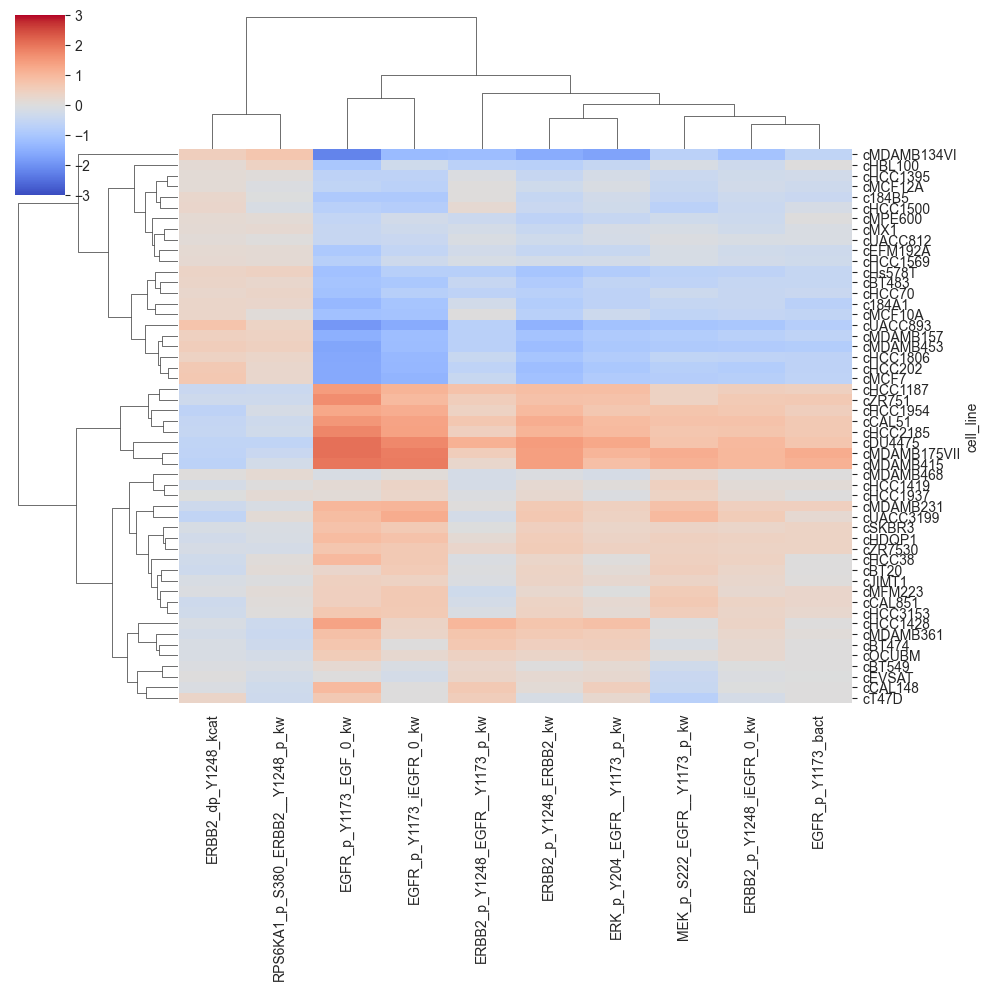

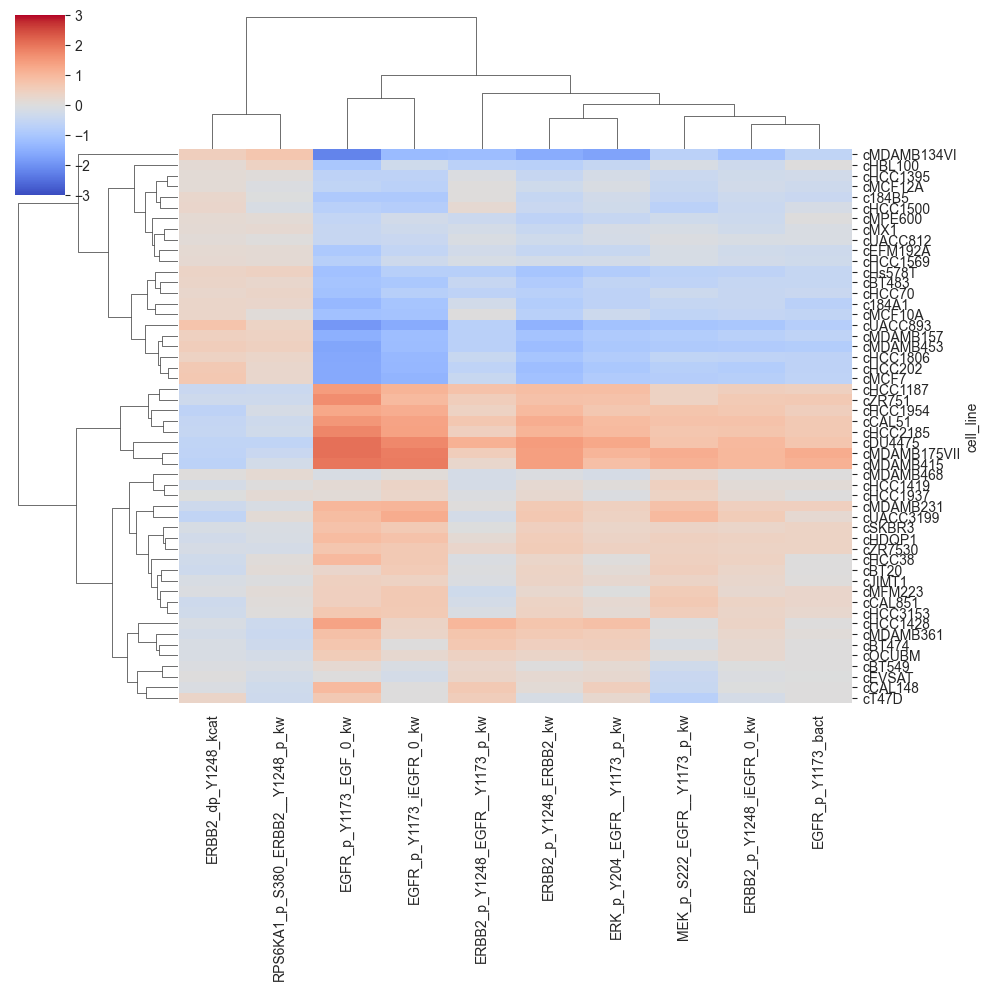

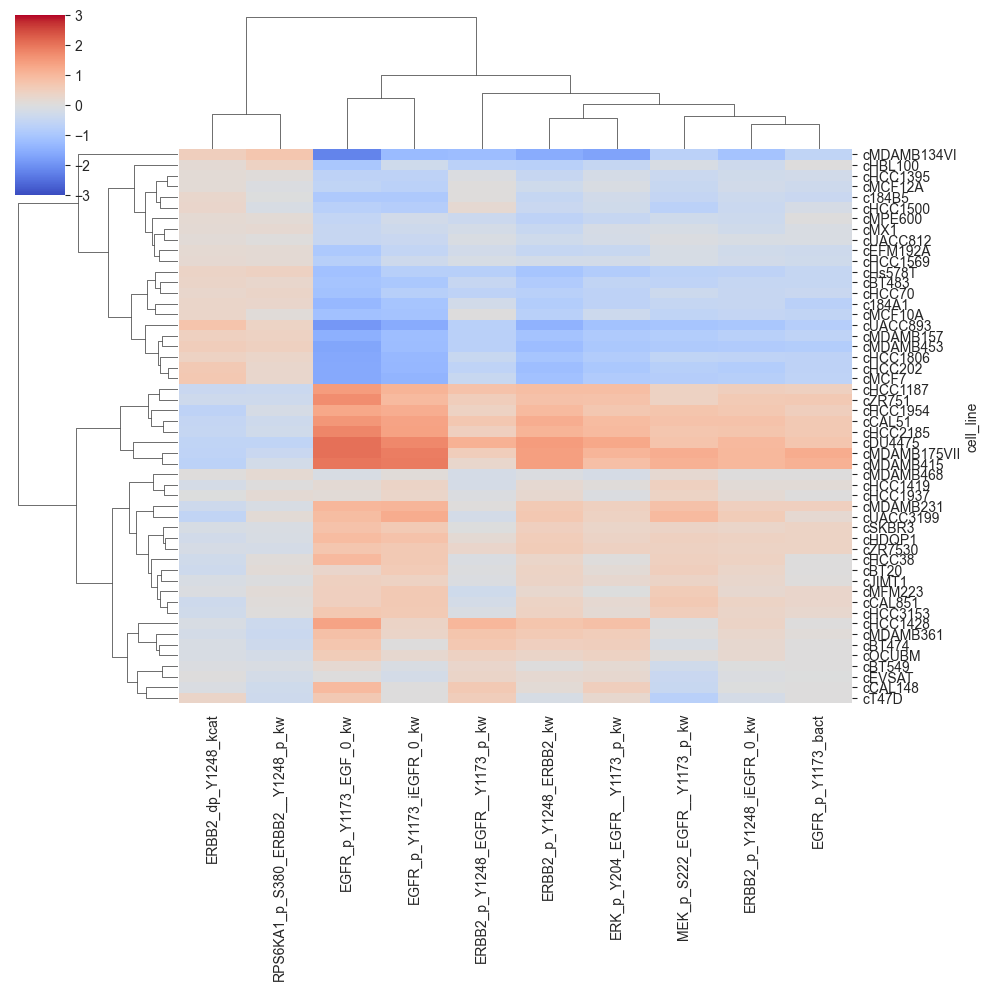

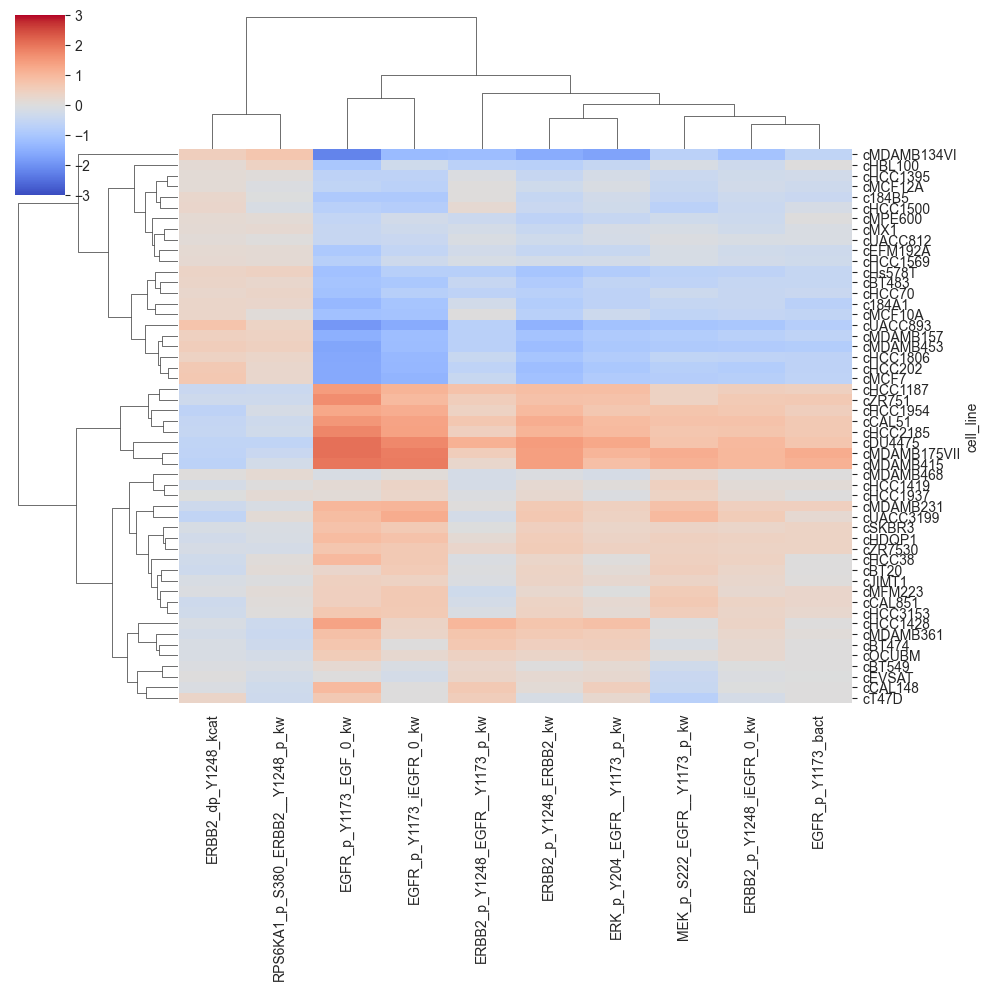

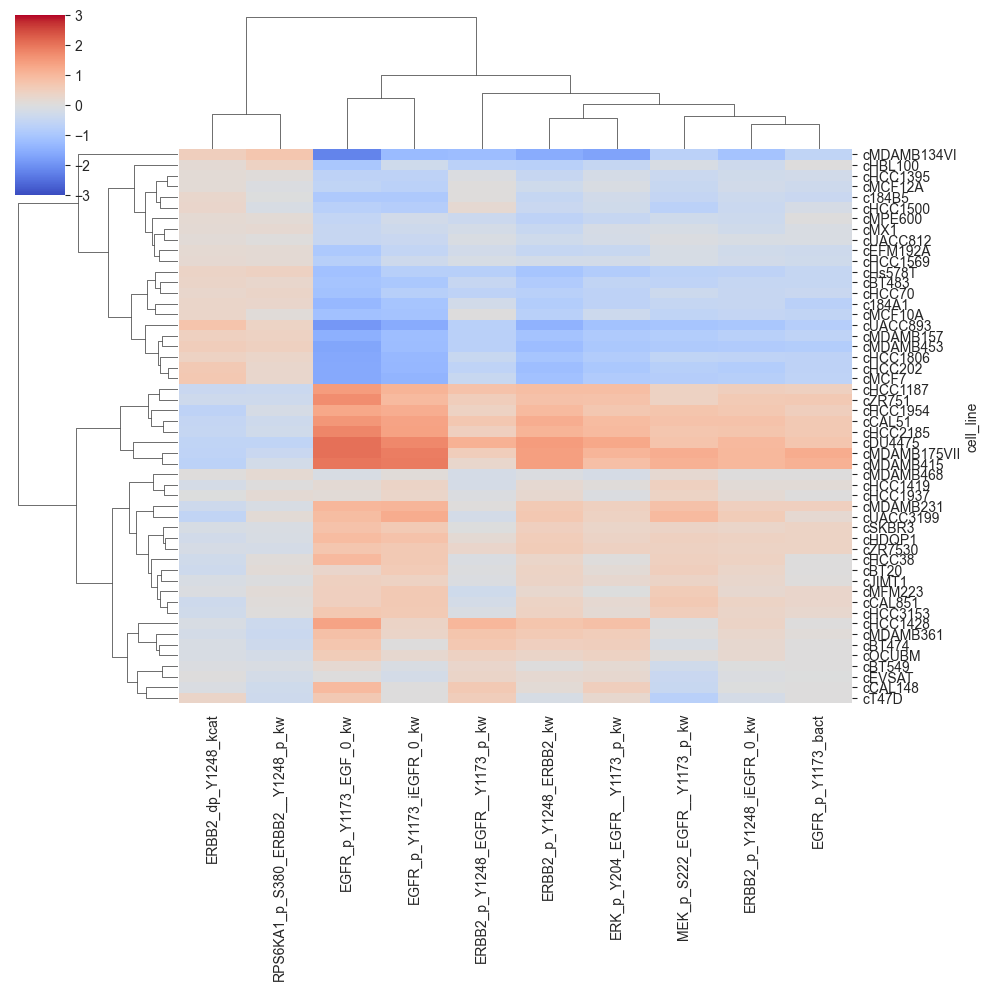

In [74]:
for samples in par_dev_df.samples.unique():
    sub_df = par_dev_df[(par_dev_df.model == "EGFR_MAPK__logobs_tegfr_aggavg") & (par_dev_df.context == "cytof_init")]
    sub_df = sub_df.groupby(["cell_line"])[top_params].median().reset_index()
    sub_df.set_index("cell_line", inplace=True)
    sns.clustermap(
        sub_df[top_params],
        cmap="coolwarm",
        vmin=-3,
        vmax=3,
        yticklabels=True,
        xticklabels=True,
    )
    plt.show()

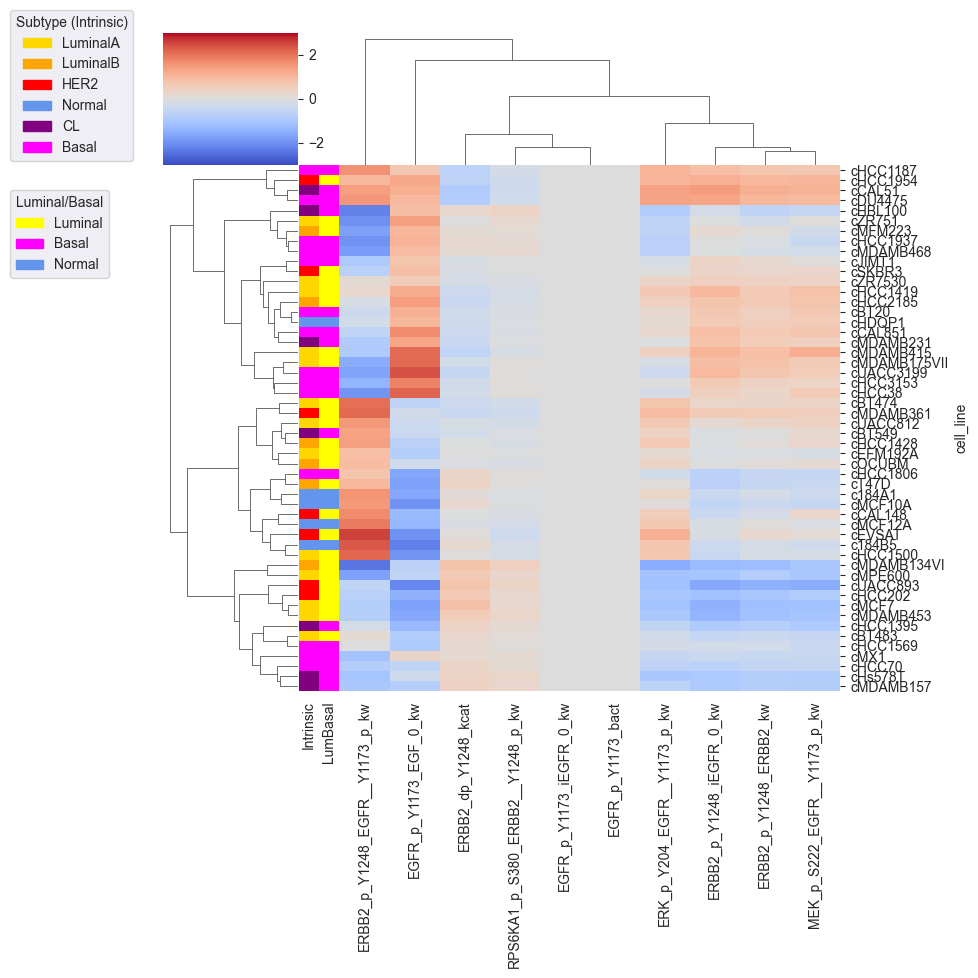

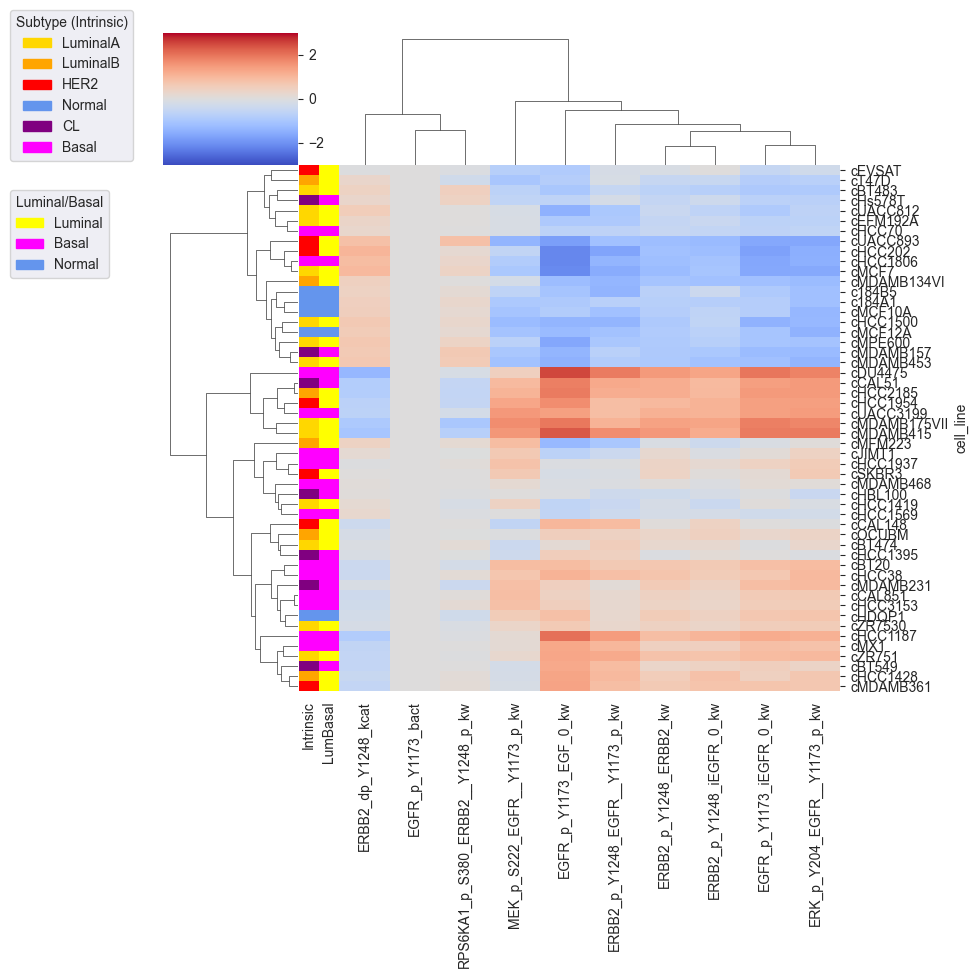

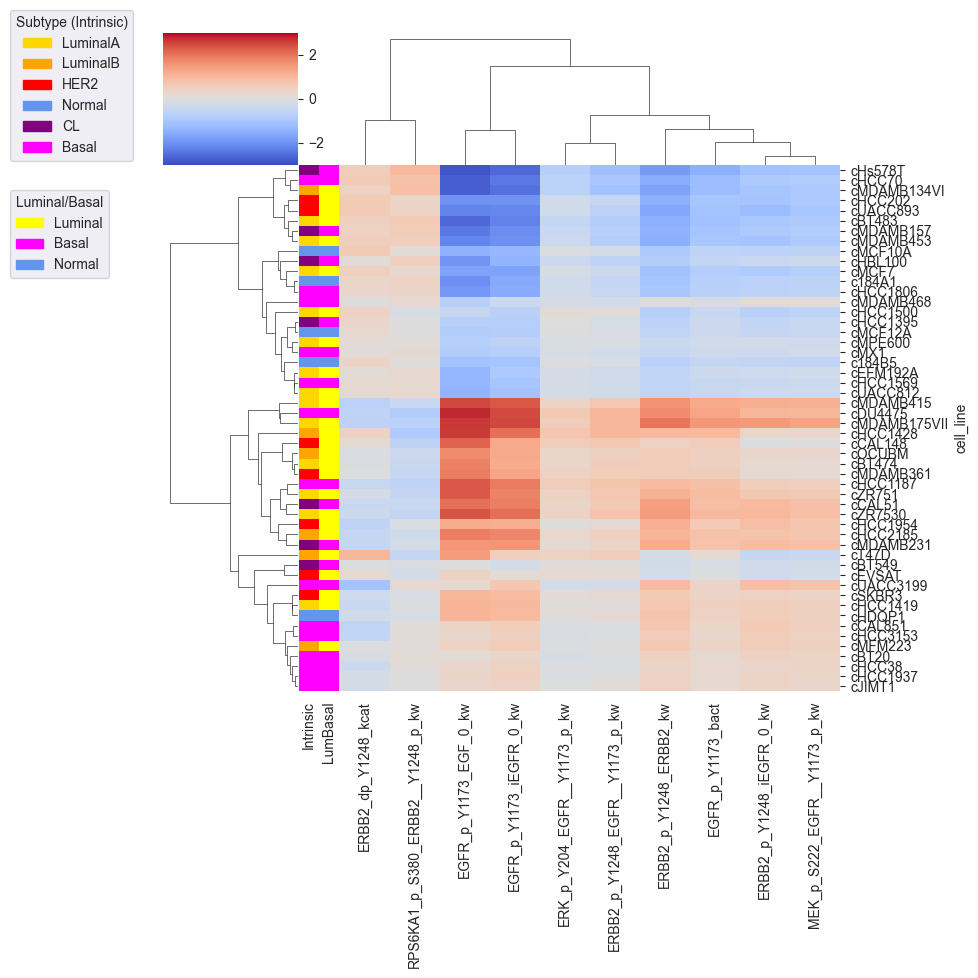

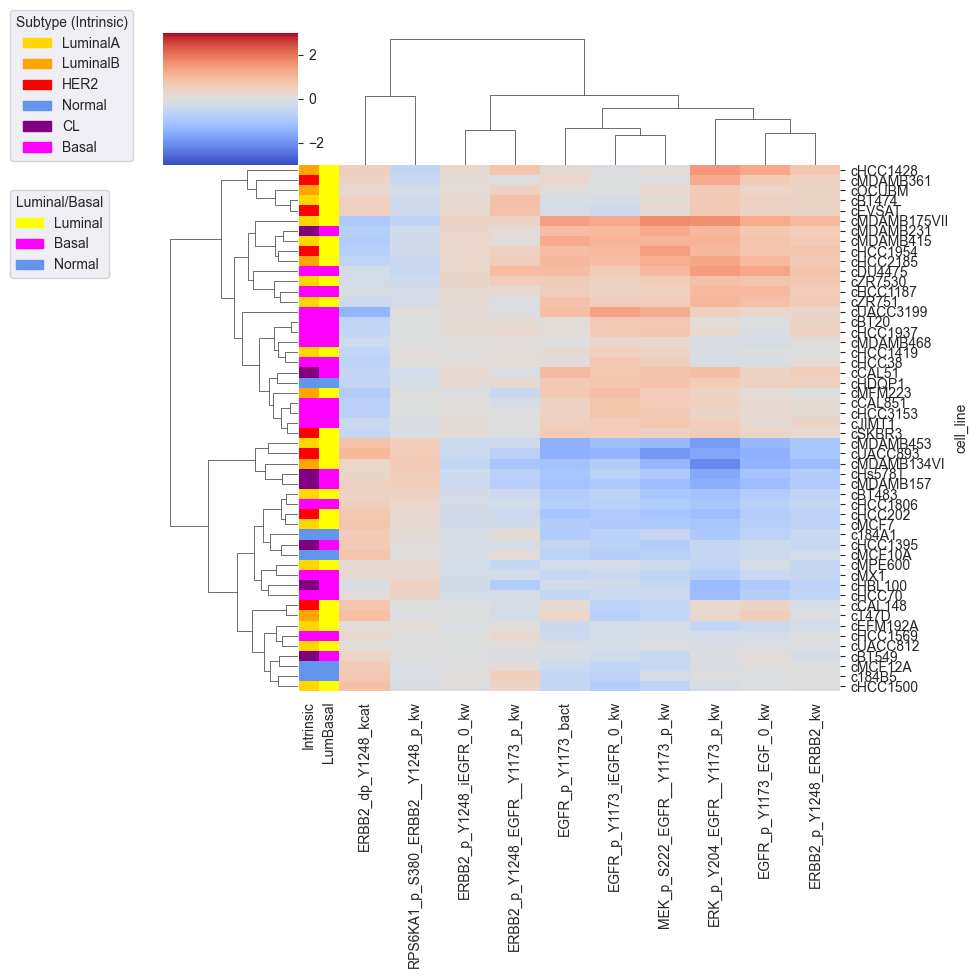

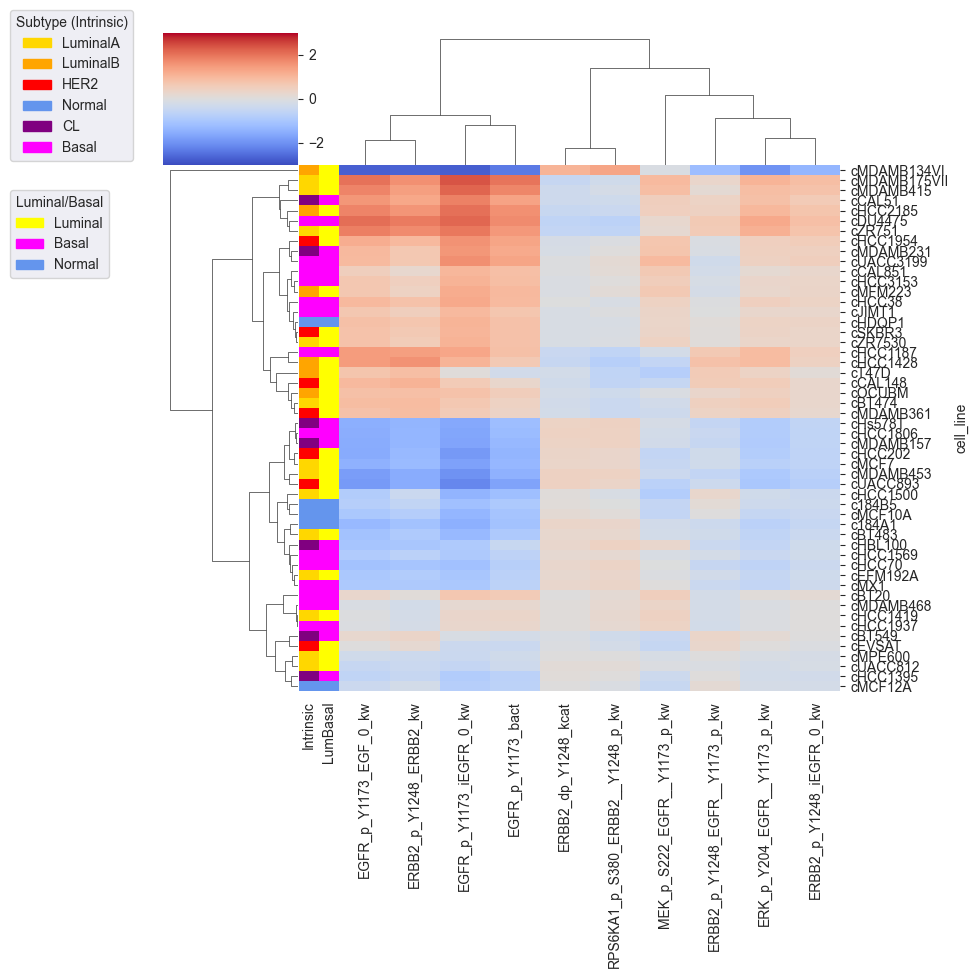

In [76]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import warnings
from annotation_utils import load_marcotte_subtypes

warnings.filterwarnings("ignore")

subtypes_marcotte = load_marcotte_subtypes(par_dev_df.cell_line.unique())


# --- 1) Pick top parameters (your logic) ---
sub_df0 = par_dev_df[(par_dev_df.model == "EGFR_MAPK__logobs_tegfr_aggavg") & (par_dev_df.context == "cytof_init")].copy()

# --- 2) Bring in subtype annotations and create Luminal/Basal collapsed label ---
# (You already built `subtypes_marcotte` above; reuse it here.)
ann = subtypes_marcotte.copy()
ann["luminalbasal"] = ann["subtype_intrinsic"].replace(
    {"LuminalA": "Luminal", "LuminalB": "Luminal", "HER2": "Luminal", "CL": "Basal"}
)

# Align annotations to clustermap index; fill missing
ann = ann.reindex(sub_df.index)
ann["subtype_intrinsic"] = ann["subtype_intrinsic"].fillna("Unknown")
ann["luminalbasal"] = ann["luminalbasal"].fillna("Unknown")

# --- 3) Color lookups for row annotations ---
intrinsic_order = ["LuminalA", "LuminalB", "HER2", "Normal", "CL", "Basal", "Unknown"]
lut_intrinsic = {
    "LuminalA": "gold",
    "LuminalB": "orange",
    "HER2": "red",
    "CL": "purple",
    "Basal": "magenta",
    "Normal": "cornflowerblue",
    "Unknown": "darkgray",
}

lb_order = ["Luminal", "Basal", "Normal", "Unknown"]
lut_lb = {
    "Luminal": "yellow",
    "Basal": "magenta",
    "Normal": "cornflowerblue",
    "Unknown": "darkgray",
}

row_colors = pd.DataFrame({
    "Intrinsic": ann["subtype_intrinsic"].map(lut_intrinsic),
    "LumBasal": ann["luminalbasal"].map(lut_lb),
}, index=sub_df.index)

# --- 5) Plot clustermap with annotations ---
for samples in ["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"]:
    sub_df = (
        sub_df0[sub_df0.samples == samples].groupby("cell_line")[list(top_params)]
        .median()
        .reset_index()
        .set_index("cell_line")
        .sort_index()
    )
    g = sns.clustermap(
        sub_df[top_params],
        cmap="coolwarm",
        vmin=-3, vmax=3,
        row_colors=row_colors,
        yticklabels=True,
        xticklabels=True,
        figsize=(10, 10),
    )

    # --- 6) Legends for the row/column annotations ---
    # Row legends
    row_patches_intrinsic = [Patch(color=lut_intrinsic[k], label=k) for k in intrinsic_order if k in ann["subtype_intrinsic"].unique()]
    row_patches_lb = [Patch(color=lut_lb[k], label=k) for k in lb_order if k in ann["luminalbasal"].unique()]


    # Place legends (use g.fig not plt)
    leg1 = g.fig.legend(handles=row_patches_intrinsic, title="Subtype (Intrinsic)", loc="upper left", bbox_to_anchor=(0.02, 0.98))
    leg2 = g.fig.legend(handles=row_patches_lb, title="Luminal/Basal", loc="upper left", bbox_to_anchor=(0.02, 0.80))

    # Avoid legend overlap with heatmap
    g.fig.subplots_adjust(left=0.18, top=0.95)
    plt.savefig(f"{samples}_clustermap_multimodal_3_cytof_init_tEGFR_aggavg.svg")
    plt.show()